In [28]:
import random 
import gym
import numpy as np
import collections
from tqdm import tqdm
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import rl_utils

In [29]:
class PolicyNet(torch.nn.Module):
    def __init__(self,state_dim,hidden_dim,action_dim):
        super().__init__()
        self.fc1 = torch.nn.Linear(state_dim,hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim,action_dim)

    def forward(self,x):
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x),dim=1)


In [30]:
class REINFORCE:
    def __init__(self,state_dim,hidden_dim,action_dim,learning_rate,gamma,device):
        self.policy_net = PolicyNet(state_dim,hidden_dim,action_dim).to(device)
        self.optimizer = torch.optim.Adam(self.policy_net.parameters(),lr=learning_rate)
        self.gamma = gamma
        self.device = device
    def take_action(self,state):
        state = torch.tensor([state],dtype=torch.float).to(self.device)
        probs = self.policy_net(state)
        action_dist = torch.distributions.Categorical(probs)
        action = action_dist.sample()
        return action.item()
    def update(self,transition_dict):
        reward_list = transition_dict["rewards"]
        state_list = transition_dict["states"]
        action_list = transition_dict["actions"]

        G = 0
        self.optimizer.zero_grad()
        for i in reversed(range(len(reward_list))):
            reward = reward_list[i]
            state = torch.tensor([state_list[i]],dtype=torch.float).to(self.device)
            action = torch.tensor([action_list[i]]).view(-1,1).to(self.device)
            log_prob = torch.log(self.policy_net(state).gather(1,action))
            G = self.gamma*G + reward
            loss = -log_prob * G
            loss.backward()
        self.optimizer.step()

In [31]:
learning_rate = 1e-3
num_episodes = 1000
hidden_dim = 128
gamma = 0.98
device = "cuda"

env_name = "CartPole-v0"
env = gym.make(env_name)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = REINFORCE(state_dim,hidden_dim,action_dim,learning_rate,gamma,device)

return_list = []
for i in range(10):
    with tqdm(total=int(num_episodes/10),desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes/10)):
            episode_return = 0
            transition_dict = {
                "states":[],
                "actions":[],
                "next_states":[],
                "rewards":[],
                "dones":[]
            }
            state,_ = env.reset()
            done = False
            while not done:
                action = agent.take_action(state)
                next_state, reward, done, truncated, _ = env.step(action)
                done = done or truncated
                transition_dict["states"].append(state)
                transition_dict["actions"].append(action)
                transition_dict["next_states"].append(next_state)
                transition_dict["rewards"].append(reward)
                transition_dict["dones"].append(done)

                state = next_state
                episode_return += reward  
            return_list.append(episode_return)      
            agent.update(transition_dict)
            if (i_episode+1)%10 == 0:
                pbar.set_postfix({'episode':'%d'%(num_episodes/10 * i + i_episode + 1),'return':'%.3f'%np.mean(return_list[-10:])})
            pbar.update(1)

/home/ricaedo/下载/yes/envs/AutoGluon/lib/python3.9/site-packages/gym/envs/registration.py:555: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
Iteration 9: 100%|██████████| 100/100 [00:07<00:00, 13.32it/s, episode=1000, return=155.000]


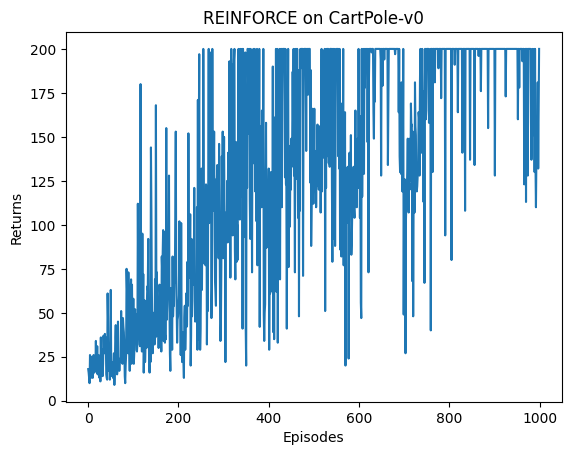

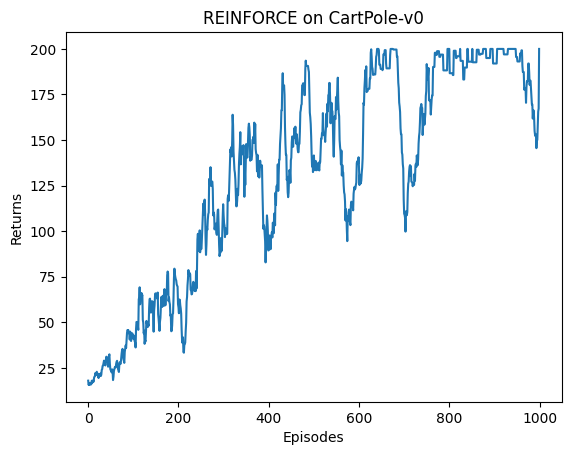

In [32]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list,return_list)
plt.xlabel("Episodes")
plt.ylabel('Returns')
plt.title('REINFORCE on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list,9)
plt.plot(episodes_list,mv_return)
plt.xlabel("Episodes")
plt.ylabel('Returns')
plt.title('REINFORCE on {}'.format(env_name))
plt.show()